<a href="https://colab.research.google.com/github/chethanks506-dot/NLP-Workbench/blob/main/NLP_Lab_1_Text_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

             NLP TEXT PREPROCESSING PIPELINE

Dataset: NLTK Reuters Corpus
Total documents available: 10788

Processing documents...

Processed 1000/10788 documents
Processed 2000/10788 documents
Processed 3000/10788 documents
Processed 4000/10788 documents
Processed 5000/10788 documents
Processed 6000/10788 documents
Processed 7000/10788 documents
Processed 8000/10788 documents
Processed 9000/10788 documents
Processed 10000/10788 documents


                 PREPROCESSING REPORT

Documents processed              : 10,788
Total original tokens           : 1,376,405
Tokens after stop-word removal   : 941,098
Final tokens after stemming      : 941,098
Unique stemmed tokens            : 42,498
Average tokens/document          : 127.59
Average final tokens/document    : 87.24
Token reduction                  : 31.63%
Execution time                   : 24.61 seconds


             TOP 20 MOST FREQUENT WORDS

   word  frequency
   said      25376
    mln      18605
     vs      14340
    dlr

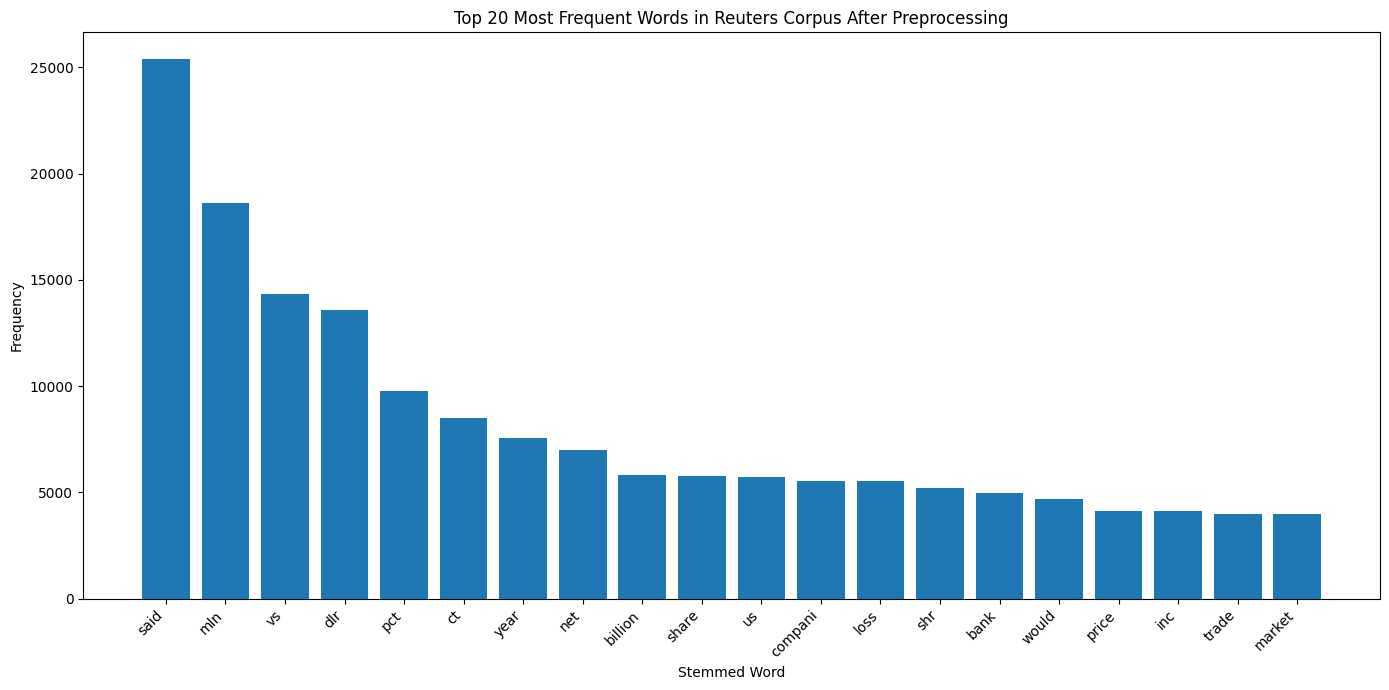



                    COMPLETED

Generated files:
1. document_preprocessing_statistics.csv
2. top_20_word_frequency.csv

NLP Pipeline:
Raw Text
   ↓
Lowercasing
   ↓
Punctuation Removal
   ↓
Tokenization
   ↓
Stop-word Removal
   ↓
Stemming
   ↓
Corpus Analysis
   ↓
Word Frequency + Statistics


In [ ]:
# ============================================================
# NLP LAB 1 - TEXT PREPROCESSING & CORPUS ANALYSIS
# Tokenization + Stop-word Removal + Stemming
# Dataset: NLTK Reuters Corpus
# ============================================================


# ------------------------------------------------------------
# 1. INSTALL / IMPORT LIBRARIES
# ------------------------------------------------------------

!pip install -q nltk pandas matplotlib


import nltk
import string
import time

import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from nltk.corpus import reuters
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


# ------------------------------------------------------------
# 2. DOWNLOAD REQUIRED NLTK DATA
# ------------------------------------------------------------

nltk.download('reuters', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)


# ------------------------------------------------------------
# 3. INITIALIZE NLP COMPONENTS
# ------------------------------------------------------------

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


# ------------------------------------------------------------
# 4. TEXT PREPROCESSING FUNCTION
# ------------------------------------------------------------

def preprocess_text(text):

    # Step 1: Convert text to lowercase
    text = text.lower()

    # Step 2: Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Step 3: Tokenization
    tokens = word_tokenize(text)

    # Step 4: Stop-word removal
    filtered_tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # Step 5: Stemming
    stemmed_tokens = [
        stemmer.stem(word)
        for word in filtered_tokens
    ]

    return tokens, filtered_tokens, stemmed_tokens


# ------------------------------------------------------------
# 5. LOAD REUTERS CORPUS
# ------------------------------------------------------------

documents = reuters.fileids()

print("=" * 65)
print("             NLP TEXT PREPROCESSING PIPELINE")
print("=" * 65)

print("\nDataset: NLTK Reuters Corpus")
print("Total documents available:", len(documents))


# ------------------------------------------------------------
# 6. PROCESS ALL DOCUMENTS
# ------------------------------------------------------------

start_time = time.time()

results = []

# Store all processed/stemmed words for frequency analysis
all_stemmed_words = []

print("\nProcessing documents...\n")


for i, doc_id in enumerate(documents):

    # Read raw document
    text = reuters.raw(doc_id)

    # Apply preprocessing pipeline
    tokens, filtered_tokens, stemmed_tokens = preprocess_text(text)

    # Store processed words
    all_stemmed_words.extend(stemmed_tokens)

    # Store document-level statistics
    results.append({
        "document": doc_id,
        "original_tokens": len(tokens),
        "after_stopword_removal": len(filtered_tokens),
        "final_tokens": len(stemmed_tokens),
        "unique_tokens": len(set(stemmed_tokens))
    })

    # Progress display every 1000 documents
    if (i + 1) % 1000 == 0:
        print(f"Processed {i + 1}/{len(documents)} documents")


end_time = time.time()

execution_time = end_time - start_time


# ------------------------------------------------------------
# 7. CREATE DATAFRAME
# ------------------------------------------------------------

results_df = pd.DataFrame(results)


# ------------------------------------------------------------
# 8. CORPUS-LEVEL STATISTICS
# ------------------------------------------------------------

total_documents = len(results_df)

total_original_tokens = results_df[
    "original_tokens"
].sum()

total_after_stopwords = results_df[
    "after_stopword_removal"
].sum()

total_final_tokens = results_df[
    "final_tokens"
].sum()

total_unique_tokens = len(set(all_stemmed_words))


# Calculate reduction percentage

token_reduction = (
    (total_original_tokens - total_final_tokens)
    / total_original_tokens
) * 100


average_original_tokens = results_df[
    "original_tokens"
].mean()

average_final_tokens = results_df[
    "final_tokens"
].mean()


# ------------------------------------------------------------
# 9. DISPLAY PREPROCESSING REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("                 PREPROCESSING REPORT")
print("=" * 65)

print(f"\nDocuments processed              : {total_documents:,}")

print(
    f"Total original tokens           : "
    f"{total_original_tokens:,}"
)

print(
    f"Tokens after stop-word removal   : "
    f"{total_after_stopwords:,}"
)

print(
    f"Final tokens after stemming      : "
    f"{total_final_tokens:,}"
)

print(
    f"Unique stemmed tokens            : "
    f"{total_unique_tokens:,}"
)

print(
    f"Average tokens/document          : "
    f"{average_original_tokens:.2f}"
)

print(
    f"Average final tokens/document    : "
    f"{average_final_tokens:.2f}"
)

print(
    f"Token reduction                  : "
    f"{token_reduction:.2f}%"
)

print(
    f"Execution time                   : "
    f"{execution_time:.2f} seconds"
)


# ------------------------------------------------------------
# 10. WORD FREQUENCY ANALYSIS
# ------------------------------------------------------------

word_frequency = Counter(all_stemmed_words)

top_words = word_frequency.most_common(20)

frequency_df = pd.DataFrame(
    top_words,
    columns=["word", "frequency"]
)


# ------------------------------------------------------------
# 11. DISPLAY TOP 20 WORDS
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("             TOP 20 MOST FREQUENT WORDS")
print("=" * 65)

print()

print(
    frequency_df.to_string(index=False)
)


# ------------------------------------------------------------
# 12. SHOW SAMPLE DOCUMENT
# ------------------------------------------------------------

sample_document = documents[0]

sample_text = reuters.raw(sample_document)

sample_tokens, sample_filtered, sample_stemmed = (
    preprocess_text(sample_text)
)

print("\n")
print("=" * 65)
print("                 SAMPLE DOCUMENT")
print("=" * 65)

print("\nDocument ID:")
print(sample_document)

print("\nOriginal text:")
print(sample_text[:500])

print("\nFirst 30 tokens:")
print(sample_tokens[:30])

print("\nFirst 30 tokens after stop-word removal:")
print(sample_filtered[:30])

print("\nFirst 30 stemmed tokens:")
print(sample_stemmed[:30])


# ------------------------------------------------------------
# 13. VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

plt.bar(
    frequency_df["word"],
    frequency_df["frequency"]
)

plt.xlabel("Stemmed Word")
plt.ylabel("Frequency")
plt.title(
    "Top 20 Most Frequent Words "
    "in Reuters Corpus After Preprocessing"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 14. SAVE RESULTS
# ------------------------------------------------------------

results_df.to_csv(
    "document_preprocessing_statistics.csv",
    index=False
)

frequency_df.to_csv(
    "top_20_word_frequency.csv",
    index=False
)


# ------------------------------------------------------------
# 15. FINAL MESSAGE
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("                    COMPLETED")
print("=" * 65)

print("\nGenerated files:")

print("1. document_preprocessing_statistics.csv")
print("2. top_20_word_frequency.csv")

print("\nNLP Pipeline:")
print("Raw Text")
print("   ↓")
print("Lowercasing")
print("   ↓")
print("Punctuation Removal")
print("   ↓")
print("Tokenization")
print("   ↓")
print("Stop-word Removal")
print("   ↓")
print("Stemming")
print("   ↓")
print("Corpus Analysis")
print("   ↓")
print("Word Frequency + Statistics")